In [39]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. データの読み込み
file_path = r"C:\Users\human1\OneDrive - 埼玉大学\共有ファイル\共同研究\松島さん\進捗報告\12.29\12.29\データセット\照明間瞳孔径データセット.csv"
df = pd.read_csv(file_path)

# 2. 変動効果（ランダム効果）の準備
# statsmodelsで複数の変動効果（subject, number, question）を同時に扱う場合、
# 全データを一つのグループ（group=1）とし、vc_formula（分散成分公式）を使用します。
df['group'] = 1

# 3. 混合効果モデルの定義
# 固定効果: brightness_con
# 変動効果: subject, number, question (それぞれをカテゴリカル変数として指定)
model = smf.mixedlm(
    # formula="ave_pupil_ave ~ brightness_con",
    formula="ave_pupil_ave_std ~ brightness_con", 
    data=df, 
    groups=df["group"],
    vc_formula={
        "subject": "0 + C(subject)",
        "number": "0 + C(number)",
        "question": "0 + C(question)"
    }
)

# 4. モデルの適合（計算実行）
result = model.fit()

# 5. 解析結果の表示
print("--- [1] 固定効果の結果 (全体の傾向) ---")
# 固定効果の係数、標準誤差、p値などが表示されます
print(result.summary().tables[1])

print("\n--- [2] 変動効果の分散成分 ---")
# 各要素（subject, number, question）がどれくらいバラついているかを示します
print(result.vcomp)

print("\n--- [3] 変動効果の個別の係数 (BLUPs) ---")
# 各被験者や各問題が、全体の平均からどれだけズレているかの予測値です
# result.random_effects は辞書形式で返されるため、グループ「1」の結果を取得します
random_effects = result.random_effects[1]
for key, value in random_effects.items():
    print(f"{key}: {value:.4f}")

# (補足) 特定の被験者に対する最終的な係数を知りたい場合
# 例: 被験者1の切片 = 固定効果の切片 + subject 1 のランダム効果
intercept_fixed = result.params['Intercept']
subject1_effect = random_effects['subject[C(subject)[1]]']
print(f"\n被験者1の独自の切片推定値: {intercept_fixed + subject1_effect:.4f}")

--- [1] 固定効果の結果 (全体の傾向) ---
                 Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept        1.727    0.238   7.264  0.000   1.261   2.193
brightness_con  -0.007    0.001  -9.434  0.000  -0.009  -0.006
number Var       0.000    0.083                               
question Var     0.012    0.110                               
subject Var      0.057    0.277                               

--- [2] 変動効果の分散成分 ---
[5.01597231e-10 1.19380892e-02 5.68884800e-02]

--- [3] 変動効果の個別の係数 (BLUPs) ---
number[C(number)[1]]: -0.0000
number[C(number)[2]]: -0.0000
number[C(number)[3]]: -0.0000
number[C(number)[4]]: 0.0000
number[C(number)[5]]: -0.0000
number[C(number)[6]]: 0.0000
question[C(question)[1]]: -0.0935
question[C(question)[2]]: -0.0128
question[C(question)[3]]: -0.0166
question[C(question)[4]]: 0.0362
question[C(question)[5]]: 0.0039
question[C(question)[6]]: 0.0828
subject[C(subject)[1]]: -0.1633
subject[C(subject)[2]]: -0.0780
subject[C(subject)[3]]: 0.2413

被験者1の独自の切片推定値: 1.

c:\Users\human1\je\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [40]:
# 1. データの読み込み
file_path = r"C:\Users\human1\OneDrive - 埼玉大学\共有ファイル\共同研究\松島さん\進捗報告\12.29\12.29\データセット\照明間瞳孔径データセット.csv"
df = pd.read_csv(file_path)

In [41]:
df["brightness_z"] = (df["brightness_con"] - df["brightness_con"].mean()) / df["brightness_con"].std()
df["number_z"] = (df["number"] - df["number"].mean()) / df["number"].std()


In [42]:
model = smf.mixedlm(
    # "ave_pupil_ave ~ brightness_z * number_z",
    "ave_pupil_ave_std ~ brightness_z * number_z",
    data=df,
    groups="subject",
    vc_formula={"question": "0 + C(question)"}
)

result = model.fit(method="lbfgs")
print(result.summary())


             Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: ave_pupil_ave_std
No. Observations:  18      Method:             REML             
No. Groups:        3       Scale:              0.0787           
Min. group size:   6       Log-Likelihood:     -12.0653         
Max. group size:   6       Converged:          Yes              
Mean group size:   6.0                                          
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.087    0.096  0.898 0.369 -0.102  0.275
brightness_z          -0.713    0.122 -5.843 0.000 -0.952 -0.474
number_z               0.039    0.125  0.314 0.754 -0.205  0.284
brightness_z:number_z -0.027    0.039 -0.691 0.490 -0.103  0.049
question Var           0.079                                    



c:\Users\human1\je\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [43]:
result.random_effects

{np.int64(1): question[C(question)[1]]   -0.307539
 question[C(question)[2]]   -0.027789
 question[C(question)[3]]    0.032911
 question[C(question)[4]]    0.014414
 question[C(question)[5]]   -0.060820
 question[C(question)[6]]   -0.273457
 dtype: float64,
 np.int64(2): question[C(question)[1]]   -0.143712
 question[C(question)[2]]   -0.145117
 question[C(question)[3]]   -0.213036
 question[C(question)[4]]    0.039649
 question[C(question)[5]]   -0.057089
 question[C(question)[6]]    0.251041
 dtype: float64,
 np.int64(3): question[C(question)[1]]   -0.026555
 question[C(question)[2]]    0.146489
 question[C(question)[3]]    0.122742
 question[C(question)[4]]    0.130749
 question[C(question)[5]]    0.130697
 question[C(question)[6]]    0.386421
 dtype: float64}

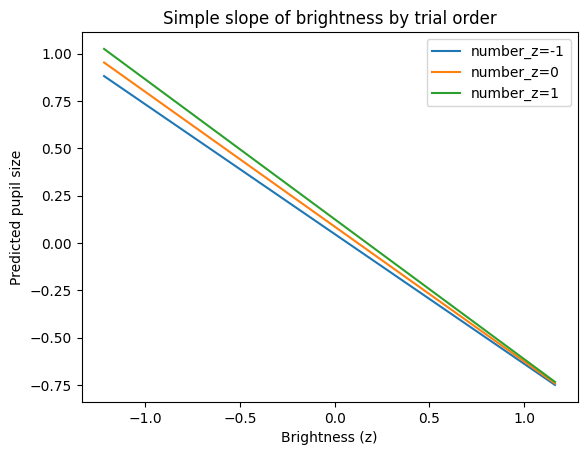

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# number の代表値
number_vals = [-1, 0, 1]

brightness_range = np.linspace(
    df["brightness_z"].min(),
    df["brightness_z"].max(),
    50
)

for n in number_vals:
    pred_df = pd.DataFrame({
        "brightness_z": brightness_range,
        "number_z": n,
        "subject": df["subject"].iloc[0],
        "question": df["question"].iloc[0]
    })
    y_pred = result.predict(pred_df)
    plt.plot(brightness_range, y_pred, label=f"number_z={n}")

plt.xlabel("Brightness (z)")
plt.ylabel("Predicted pupil size")
plt.legend()
plt.title("Simple slope of brightness by trial order")
plt.show()


In [45]:
model_cat = smf.mixedlm(
    # "ave_pupil_ave ~ C(brightness_con) + number_z",
    "ave_pupil_ave_std ~ C(brightness_con) + number_z",
    data=df,
    groups="subject",
    vc_formula={"question": "0 + C(question)"}
)
result_cat = model_cat.fit()
print(result_cat.summary())


                   Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     ave_pupil_ave_std
No. Observations:      18          Method:                 REML             
No. Groups:            3           Scale:                  0.0716           
Min. group size:       6           Log-Likelihood:         -10.1030         
Max. group size:       6           Converged:              Yes              
Mean group size:       6.0                                                  
----------------------------------------------------------------------------
                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                         1.002    0.137   7.324 0.000  0.734  1.271
C(brightness_con)[T.230.4666667] -1.121    0.173  -6.486 0.000 -1.460 -0.782
C(brightness_con)[T.334.8]       -1.674    0.110 -15.212 0.000 -1.890 -1.459
number_z           

c:\Users\human1\je\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [46]:
import pymc as pm
import numpy as np

# インデックス化
subject_idx = df["subject"].astype("category").cat.codes.values
question_idx = df["question"].astype("category").cat.codes.values

n_subject = len(np.unique(subject_idx))
n_question = len(np.unique(question_idx))

brightness = df["brightness_z"].values
number = df["number_z"].values
# y = df["ave_pupil_ave"].values
y = df["ave_pupil_ave_std"].values

with pm.Model() as model:

    # 固定効果（弱情報事前分布）
    beta_0 = pm.Normal("beta_0", 0, 1)
    beta_brightness = pm.Normal("beta_brightness", 0, 1)
    beta_number = pm.Normal("beta_number", 0, 1)

    # ランダム効果の分散
    sigma_subject = pm.HalfNormal("sigma_subject", 1)
    sigma_question = pm.HalfNormal("sigma_question", 1)

    # ランダム効果（BLUP）
    subject_offset = pm.Normal("subject_offset", 0, 1, shape=n_subject)
    question_offset = pm.Normal("question_offset", 0, 1, shape=n_question)

    mu = (
        beta_0
        + beta_brightness * brightness
        + beta_number * number
        + subject_offset[subject_idx] * sigma_subject
        + question_offset[question_idx] * sigma_question
    )

    sigma = pm.HalfNormal("sigma", 1)

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    trace = pm.sample(2000, tune=2000, target_accept=0.9)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, beta_brightness, beta_number, sigma_subject, sigma_question, subject_offset, question_offset, sigma]


c:\Users\human1\je\.venv\Lib\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 803 seconds.
There were 13 divergences after tuning. Increase `target_accept` or reparameterize.


In [47]:
trace.posterior["question_offset"]

<xarray.DataArray 'question_offset' (chain: 4, draw: 2000,
                                     question_offset_dim_0: 6)> Size: 384kB
array([[[-0.95230332,  0.62296168,  0.82455956, -0.33975186,
          0.31847225,  0.37067172],
        [-0.77461585, -0.28781623,  0.32329121,  0.35307231,
          0.03988003,  1.27385875],
        [-0.31942728,  0.03992679,  0.08684963,  0.4552879 ,
          0.22049122,  0.72283438],
        ...,
        [-0.1372419 ,  0.44352712,  0.60576907,  1.47017006,
          1.09810958,  1.04373936],
        [-0.21500164,  0.16401648, -0.28037927,  0.01294376,
         -1.07782991, -0.79149945],
        [-0.77742851, -0.63802418,  1.3129166 , -0.32744314,
         -0.20249527,  1.27755041]],

       [[-0.23044202, -1.86728497,  0.00669191, -0.39733573,
         -0.21049672,  0.26834133],
        [ 0.46308861, -1.5214287 ,  0.61021726,  0.36753751,
         -0.62828829,  0.35236191],
        [ 0.26095171, -1.14031115, -0.20026601, -0.06256856,
         -0.06060801,  0.73594717],
...
        [-0.79171323,  1.02661267, -0.27191263,  0.19087818,
         -0.53108103,  1.1193067 ],
        [-0.35589652,  0.22141001,  0.13479935,  0.39358419,
         -0.1483444 , -0.11824105],
        [-1.60259387, -0.79404194, -0.7475923 , -1.01512255,
         -0.31490378,  0.73155827]],

       [[ 0.43925106,  0.91661674, -0.71280402,  1.72876708,
          0.53219255,  0.63525278],
        [-0.48751649, -1.07319565, -0.65632822, -0.55594598,
          0.56923446, -0.75797697],
        [ 0.85478753,  0.23275218, -0.16730532,  1.12458676,
          0.45338896,  0.93480059],
        ...,
        [-0.91399691, -0.95511476,  0.10339191, -0.13760443,
         -0.2698397 , -0.80696455],
        [-1.23910671, -0.12985522, -0.33759381, -0.15612163,
          0.00498483, -0.0866029 ],
        [-1.4531431 , -1.22337711, -0.48243315,  0.36745196,
         -1.12299965, -0.18772476]]], shape=(4, 2000, 6))
Coordinates:
  * chain                  (chain) int64 32B 0 1 2 3
  * draw                   (draw) int64 16kB 0 1 2 3 4 ... 1996 1997 1998 1999
  * question_offset_dim_0  (question_offset_dim_0) int64 48B 0 1 2 3 4 5

In [48]:
import numpy as np
import pandas as pd

# question_offset: (chain, draw, question)
q_samples = trace.posterior["question_offset"].values.reshape(-1, n_question)

summary = pd.DataFrame({
    "question": [f"Q{i+1}" for i in range(n_question)],
    "mean": q_samples.mean(axis=0),
    "lower": np.percentile(q_samples, 2.5, axis=0),
    "upper": np.percentile(q_samples, 97.5, axis=0)
})


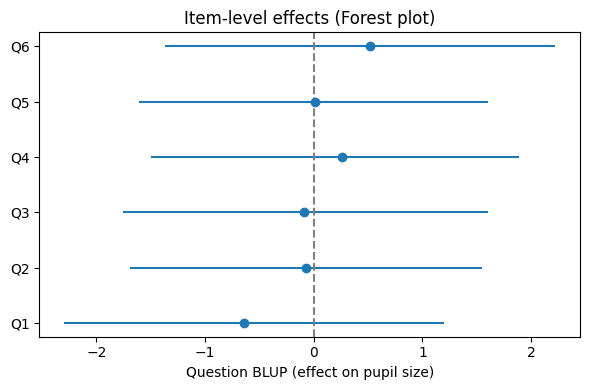

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
y_pos = range(len(summary))

plt.errorbar(
    summary["mean"],
    y_pos,
    xerr=[
        summary["mean"] - summary["lower"],
        summary["upper"] - summary["mean"]
    ],
    fmt="o"
)

plt.axvline(0, linestyle="--", color="gray")
plt.yticks(y_pos, summary["question"])
plt.xlabel("Question BLUP (effect on pupil size)")
plt.title("Item-level effects (Forest plot)")
plt.tight_layout()
plt.show()


In [50]:
b_samples = trace.posterior["beta_brightness"].values.flatten()

brightness_summary = {
    "mean": b_samples.mean(),
    "lower": np.percentile(b_samples, 2.5),
    "upper": np.percentile(b_samples, 97.5)
}


In [51]:
combined = pd.concat([
    summary.assign(type="Question"),
    pd.DataFrame({
        "question": ["Brightness"],
        "mean": [brightness_summary["mean"]],
        "lower": [brightness_summary["lower"]],
        "upper": [brightness_summary["upper"]],
        "type": ["Brightness"]
    })
])


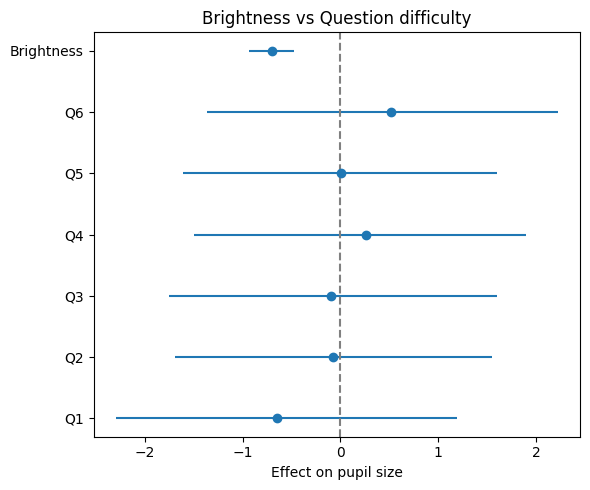

In [52]:
plt.figure(figsize=(6, 5))
y_pos = range(len(combined))

plt.errorbar(
    combined["mean"],
    y_pos,
    xerr=[
        combined["mean"] - combined["lower"],
        combined["upper"] - combined["mean"]
    ],
    fmt="o"
)

plt.axvline(0, linestyle="--", color="gray")
plt.yticks(y_pos, combined["question"])
plt.xlabel("Effect on pupil size")
plt.title("Brightness vs Question difficulty")
plt.tight_layout()
plt.show()


In [53]:
import arviz as az

# 主要なパラメータ（固定効果と各グループの分散）を指定
var_names = ["beta_0", "beta_brightness", "beta_number", "sigma_subject", "sigma_question", "sigma"]

# 要約統計量の表示 (95% HDIを指定)
summary = az.summary(trace, var_names=var_names, hdi_prob=0.95)
print(summary)

                  mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
beta_0           0.053  0.289    -0.621      0.593      0.006    0.007   
beta_brightness -0.703  0.116    -0.933     -0.475      0.002    0.002   
beta_number      0.022  0.119    -0.212      0.260      0.002    0.002   
sigma_subject    0.428  0.332     0.000      1.071      0.007    0.011   
sigma_question   0.182  0.148     0.000      0.464      0.003    0.003   
sigma            0.344  0.086     0.200      0.514      0.002    0.001   

                 ess_bulk  ess_tail  r_hat  
beta_0             2678.0    2037.0    1.0  
beta_brightness    4974.0    4935.0    1.0  
beta_number        4767.0    4544.0    1.0  
sigma_subject      1708.0    1919.0    1.0  
sigma_question     2514.0    3005.0    1.0  
sigma              3131.0    4553.0    1.0  


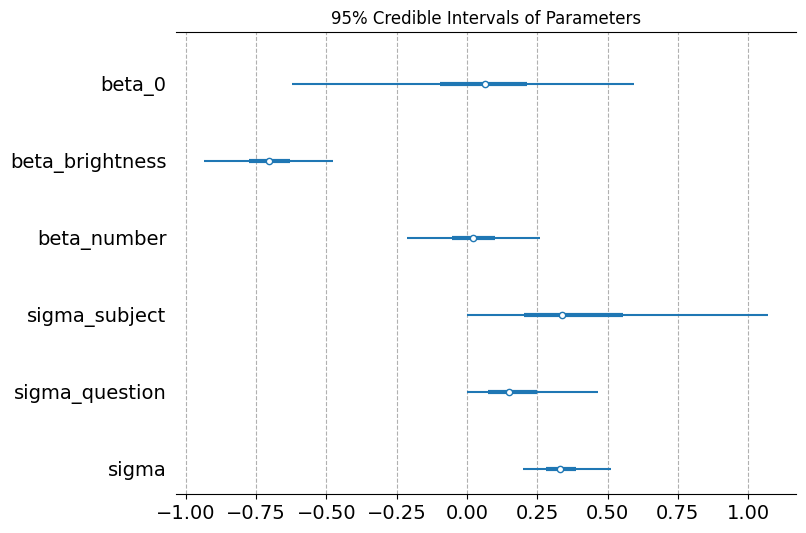

In [54]:
import matplotlib.pyplot as plt

# フォレストプロットの描画
# combined=True は複数のチェーンをまとめて表示する設定です
az.plot_forest(trace, var_names=var_names, combined=True, hdi_prob=0.95, figsize=(8, 6))

plt.title("95% Credible Intervals of Parameters")
plt.grid(True, axis='x', linestyle='--')
plt.show()